In [1]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


In [2]:
# device 준비 : cpu, gpu(cuda)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')


Using cuda device


In [3]:
# 필요 함수 생성
# 0. 데이터 준비 함수
# train_loader 를 반환하는 함수 (모델에 데이터 넣어주는 역할)
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)


    return train_loader, x_val_tensor, y_val_tensor


In [4]:
#1. 학습 함수
# 1. 학습 함수
#train함수에 들어갈 재료들(parameters)들은:dataloader, model, loss_fn, optimizer, device 
#왜냐하면 학습할때 데이터로더 부터 optimizer까지 다 필요하기 때문
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0                                     # 학습시 오차 저장하는 변수
    model.train()                                   # 훈련 모드로 설정 ("학습해라 뜻은아님, 학습할 준비를 해라"라는 뜻)
    for x, y in dataloader:     # batch : 현재 배치 번호, (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)           # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 연결


        # Feed Forward
        # feed forward의 목표는 loss를 구하고 backward하기
        # x라는 데이터로 모델을 통과시켜서 pred라는 예측값을 얻음 (32개 나옴)
        pred = model(x)               #FEED FORWARD : 순전파 학습  입력층(32 x 12), 출력층(32 x 1) 32개의 데이터가 들어가서 1개의 결과값이 나옴
        loss = loss_fn(pred, y)       #y : 원래 답(32, 1) 
        tr_loss += loss


        # Backpropagation

        #loss가지고 backward를 통해서 모델의 각 파라미터에 대한 손실의 기울기를 계산
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지


    tr_loss /= num_batches          # 모든 배치에서의 loss 평균


    return tr_loss.item()



In [5]:
#2. 평가 함수
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    #순전파만 하면된다 -> 예측값 (pred)만 구하면 된다.  즉 학습을 할필요가없다 = no grad
    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x) #예측값 나온다
        eval_loss = loss_fn(pred, y).item()    # train에 사용했던 loss function으로 예측 값 pred와 실제 값 y 사이의 손실 계산

    #eval loss(손실), 예측값 반환한다
    return eval_loss, pred


In [6]:
#3. 시각화: 학습 그래프 그린다
#각각 학습 오차 curve 확인, eval 오차 curve 확인

# 3. 시각화 함수 : 학습 그래프 그린다
def dl_learning_curve(tr_loss_list, val_loss_list): # tr_loss : 학습 오차, val_loss : 검증 오차
    epochs = list(range(1, len(tr_loss_list)+1)) # 에폭수 : 100
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # plot 점으로 선그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')  # plot 점으로 선그래프


    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()



In [7]:
# 데이터 전처리
# 데이터 로딩 및 준비
# 데이터 로딩
path = 'https://bit.ly/ds_boston_csv'
data = pd.read_csv(path)


# x, y 분할
target = 'medv'
x = data.drop(target, axis = 1) # 이번에는 12개의 입력변수 모두를 이용합니다.
y = data.loc[:, target]


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


In [8]:
# 데이터 로더
# y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values


# 데이터 로더 준비
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [10]:
# 모델링 : 모델 구조 설계
n_feature = x.shape[1]                          # 컬럼 개수
model2 = nn.Sequential(nn.Linear(n_feature, 2), # 입력 -> 12, 출력 -> 2 <= 입력층
                       nn.ReLU(),              
                       nn.Linear(2, 1)          # 2,1
                       ).to(device)



In [13]:
# 손실 함수, 옵티마이저 준비
loss_fn = nn.MSELoss()
optimizer = Adam(model2.parameters(), lr=0.01)

# Epoch 100, train loss : 30.634966, val loss : 25.394207
# 학습
epochs = 1000 # 100번 반복 학습
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)
    tr_loss_list.append(tr_loss) # learning curve 그리기 위해 리스트에 추가
    val_loss_list.append(val_loss) # learning curve 그리기 위해 리스트에 추가
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 30.736202, val loss : 25.096010
Epoch 2, train loss : 31.133465, val loss : 24.432737
Epoch 3, train loss : 30.347202, val loss : 24.452116
Epoch 4, train loss : 29.714958, val loss : 24.572090
Epoch 5, train loss : 30.111250, val loss : 24.214218
Epoch 6, train loss : 29.163815, val loss : 24.068800
Epoch 7, train loss : 29.065313, val loss : 23.653221
Epoch 8, train loss : 28.955019, val loss : 23.371502
Epoch 9, train loss : 28.568932, val loss : 23.824903
Epoch 10, train loss : 28.136806, val loss : 23.300835
Epoch 11, train loss : 27.692009, val loss : 22.919739
Epoch 12, train loss : 27.399504, val loss : 23.077635
Epoch 13, train loss : 27.681355, val loss : 22.808949
Epoch 14, train loss : 28.444447, val loss : 22.629942
Epoch 15, train loss : 27.186119, val loss : 22.979891
Epoch 16, train loss : 27.148026, val loss : 22.519680
Epoch 17, train loss : 27.751112, val loss : 22.178171
Epoch 18, train loss : 27.133175, val loss : 22.329533
Epoch 19, train los

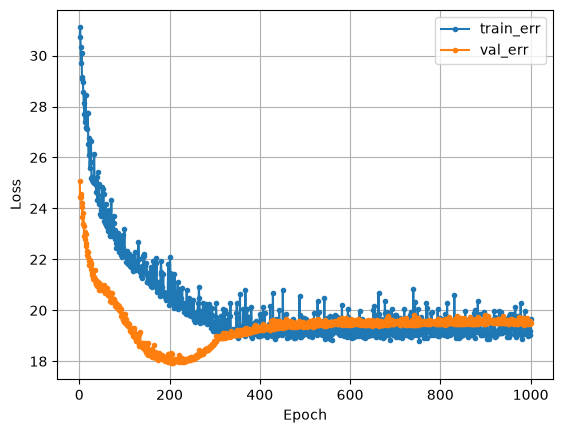

In [ ]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)
#val_Err를 봐야하는데 epoch=200 이 제일나음


In [ ]:
# 예측 결과
_, pred = evaluate(x_val_ts, y_val_ts, model2, loss_fn, device)


# 모델 평가
# 층이 더 추가된거 (neul활성화 + ) 로 회귀모델실습1보다 성능이 나아짐

mae = mean_absolute_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
mape = mean_absolute_percentage_error(y_val_ts.cpu().numpy(), pred.cpu().numpy())
print(f'MAE : {mae}')
print(f'MAPE : {mape}')


MAE : 3.4166979789733887
MAPE : 0.1811777949333191
